# Visualize the Greenhouse–Geisser Analysis

This notebook visualizes the four statistical tables produced by the upgraded A–E analysis.

### Expected files
```text
data/A_to_E_GG_omnibus.csv
data/A_to_E_GG_posthoc.csv
data/A_to_E_GG_posthoc_significant.csv
data/A_to_E_GG_master_summary.csv
```

### It creates three publication-style figures

1. **Omnibus effect map**  
   All 24 AOI × metric tests. Bubble size = partial η²; black ring = GG + FDR significant.

2. **A–E mean profiles**  
   A 3 × 8 overview showing the mean of each condition for every AOI and metric.

3. **C-focused effect-size forest plot**  
   Shows paired \(d_z\) and bootstrap 95% CI for A–C, B–C, C–D, and C–E.


In [7]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [8]:
OMNIBUS_CSV = "data/A_to_E_GG_omnibus.csv"
POSTHOC_CSV = "data/A_to_E_GG_posthoc.csv"
POSTHOC_SIG_CSV = "data/A_to_E_GG_posthoc_significant.csv"
MASTER_CSV = "data/A_to_E_GG_master_summary.csv"

AOIS = ["CTA", "Headline", "Product"]

METRICS = [
    "VAI (%)",
    "TTFF (s)",
    "Time spent (s)",
    "Fixations",
    "Fix. duration (s)",
    "FFD (s)",
    "K-coefficient",
    "Revisits",
]

CONDITIONS = ["A", "B", "C", "D", "E"]

C_PAIRS = [
    ("A", "C"),
    ("B", "C"),
    ("C", "D"),
    ("C", "E"),
]


In [9]:
for f in [OMNIBUS_CSV, POSTHOC_CSV, POSTHOC_SIG_CSV, MASTER_CSV]:
    if not Path(f).exists():
        raise FileNotFoundError(f"Could not find: {f}")

omnibus = pd.read_csv(OMNIBUS_CSV)
posthoc = pd.read_csv(POSTHOC_CSV)
posthoc_sig = pd.read_csv(POSTHOC_SIG_CSV)
master = pd.read_csv(MASTER_CSV)

for frame in [omnibus, posthoc, posthoc_sig, master]:
    frame.columns = [str(c).replace("**", "").strip() for c in frame.columns]

print("Omnibus rows:", len(omnibus))
print("Post-hoc rows:", len(posthoc))
print("Significant post-hoc rows:", len(posthoc_sig))


Omnibus rows: 24
Post-hoc rows: 70
Significant post-hoc rows: 23


## Figure 1 — Omnibus effect map

<>:86: SyntaxWarning: invalid escape sequence '\e'
<>:86: SyntaxWarning: invalid escape sequence '\e'
C:\Users\Waleed\AppData\Local\Temp\ipykernel_872\3856122215.py:86: SyntaxWarning: invalid escape sequence '\e'
  "Partial $\eta^2$",


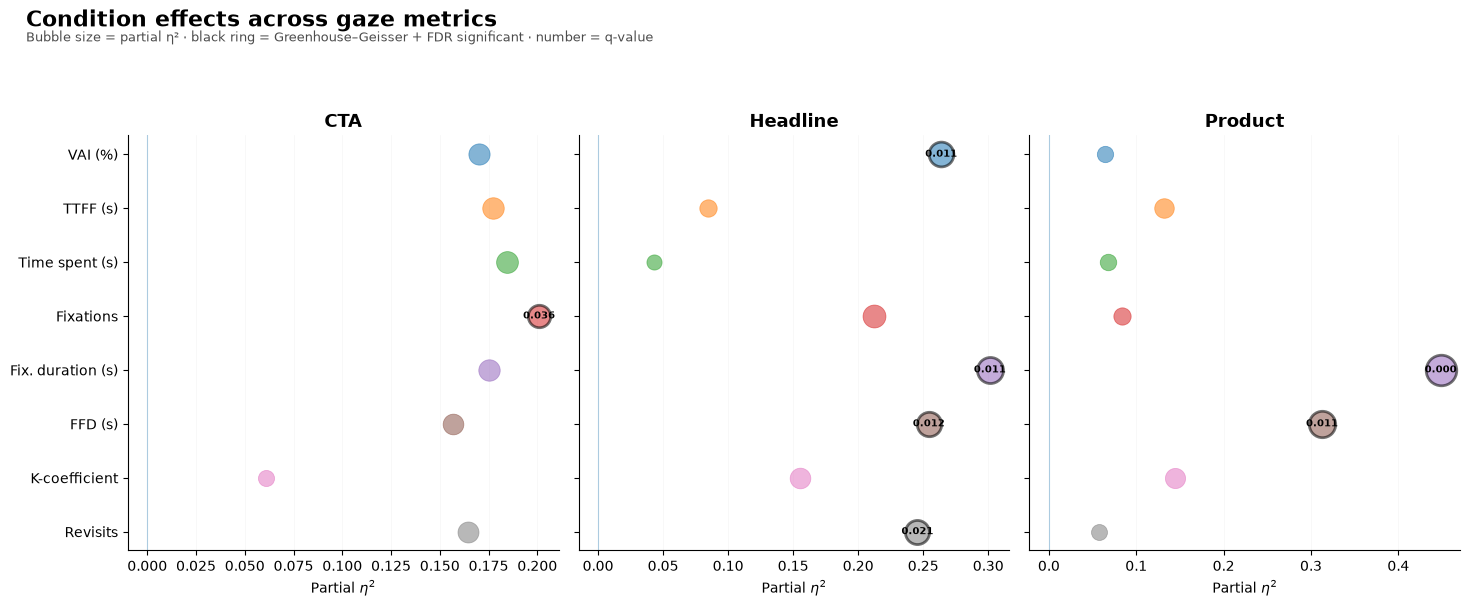

In [10]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(15.5, 6.4),
    sharey=True
)

for ax, aoi in zip(axes, AOIS):

    sub = omnibus[
        omnibus["AOI"] == aoi
    ].copy()

    # preserve metric order
    sub["metric"] = pd.Categorical(
        sub["metric"],
        categories=METRICS,
        ordered=True
    )

    sub = sub.sort_values("metric")

    y = np.arange(len(METRICS))

    eta = []
    sig = []
    qvals = []

    for metric in METRICS:
        r = sub[sub["metric"] == metric]

        if len(r) == 0:
            eta.append(np.nan)
            sig.append(False)
            qvals.append(np.nan)
        else:
            rr = r.iloc[0]
            eta.append(rr["partial_eta_sq"])
            sig.append(bool(rr["significant_GG_FDR"]))
            qvals.append(rr["q_GG_FDR"])

    eta = np.asarray(eta, dtype=float)

    # Bubble area encodes partial eta squared
    sizes = 80 + 900 * np.nan_to_num(eta, nan=0)

    for i, metric in enumerate(METRICS):
        if not np.isfinite(eta[i]):
            continue

        ax.scatter(
            eta[i],
            y[i],
            s=sizes[i],
            alpha=0.55,
            linewidth=2.0 if sig[i] else 0.6,
            edgecolor="black" if sig[i] else None,
            zorder=3
        )

        if sig[i] and np.isfinite(qvals[i]):
            ax.text(
                eta[i],
                y[i],
                f'{qvals[i]:.3f}',
                ha="center",
                va="center",
                fontsize=7,
                fontweight="bold",
                zorder=4
            )

    ax.axvline(
        0,
        linewidth=0.8,
        alpha=0.35
    )

    ax.set_title(
        aoi,
        fontsize=13,
        fontweight="bold"
    )

    ax.set_xlabel(
        "Partial $\eta^2$",
        fontsize=10
    )

    ax.grid(
        axis="x",
        linewidth=0.5,
        alpha=0.12
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

axes[0].set_yticks(np.arange(len(METRICS)))
axes[0].set_yticklabels(METRICS)
axes[0].invert_yaxis()

fig.suptitle(
    "Condition effects across gaze metrics",
    x=0.06,
    ha="left",
    fontsize=16,
    fontweight="bold"
)

fig.text(
    0.06,
    0.93,
    "Bubble size = partial η² · black ring = Greenhouse–Geisser + FDR significant · number = q-value",
    fontsize=9.5,
    alpha=0.70
)

fig.tight_layout(rect=[0.04, 0.04, 0.995, 0.90])

fig.savefig(
    "GG_omnibus_effect_map.pdf",
    bbox_inches="tight"
)

fig.savefig(
    "GG_omnibus_effect_map.png",
    dpi=500,
    bbox_inches="tight"
)

plt.show()


## Figure 2 — Mean profiles across A–E

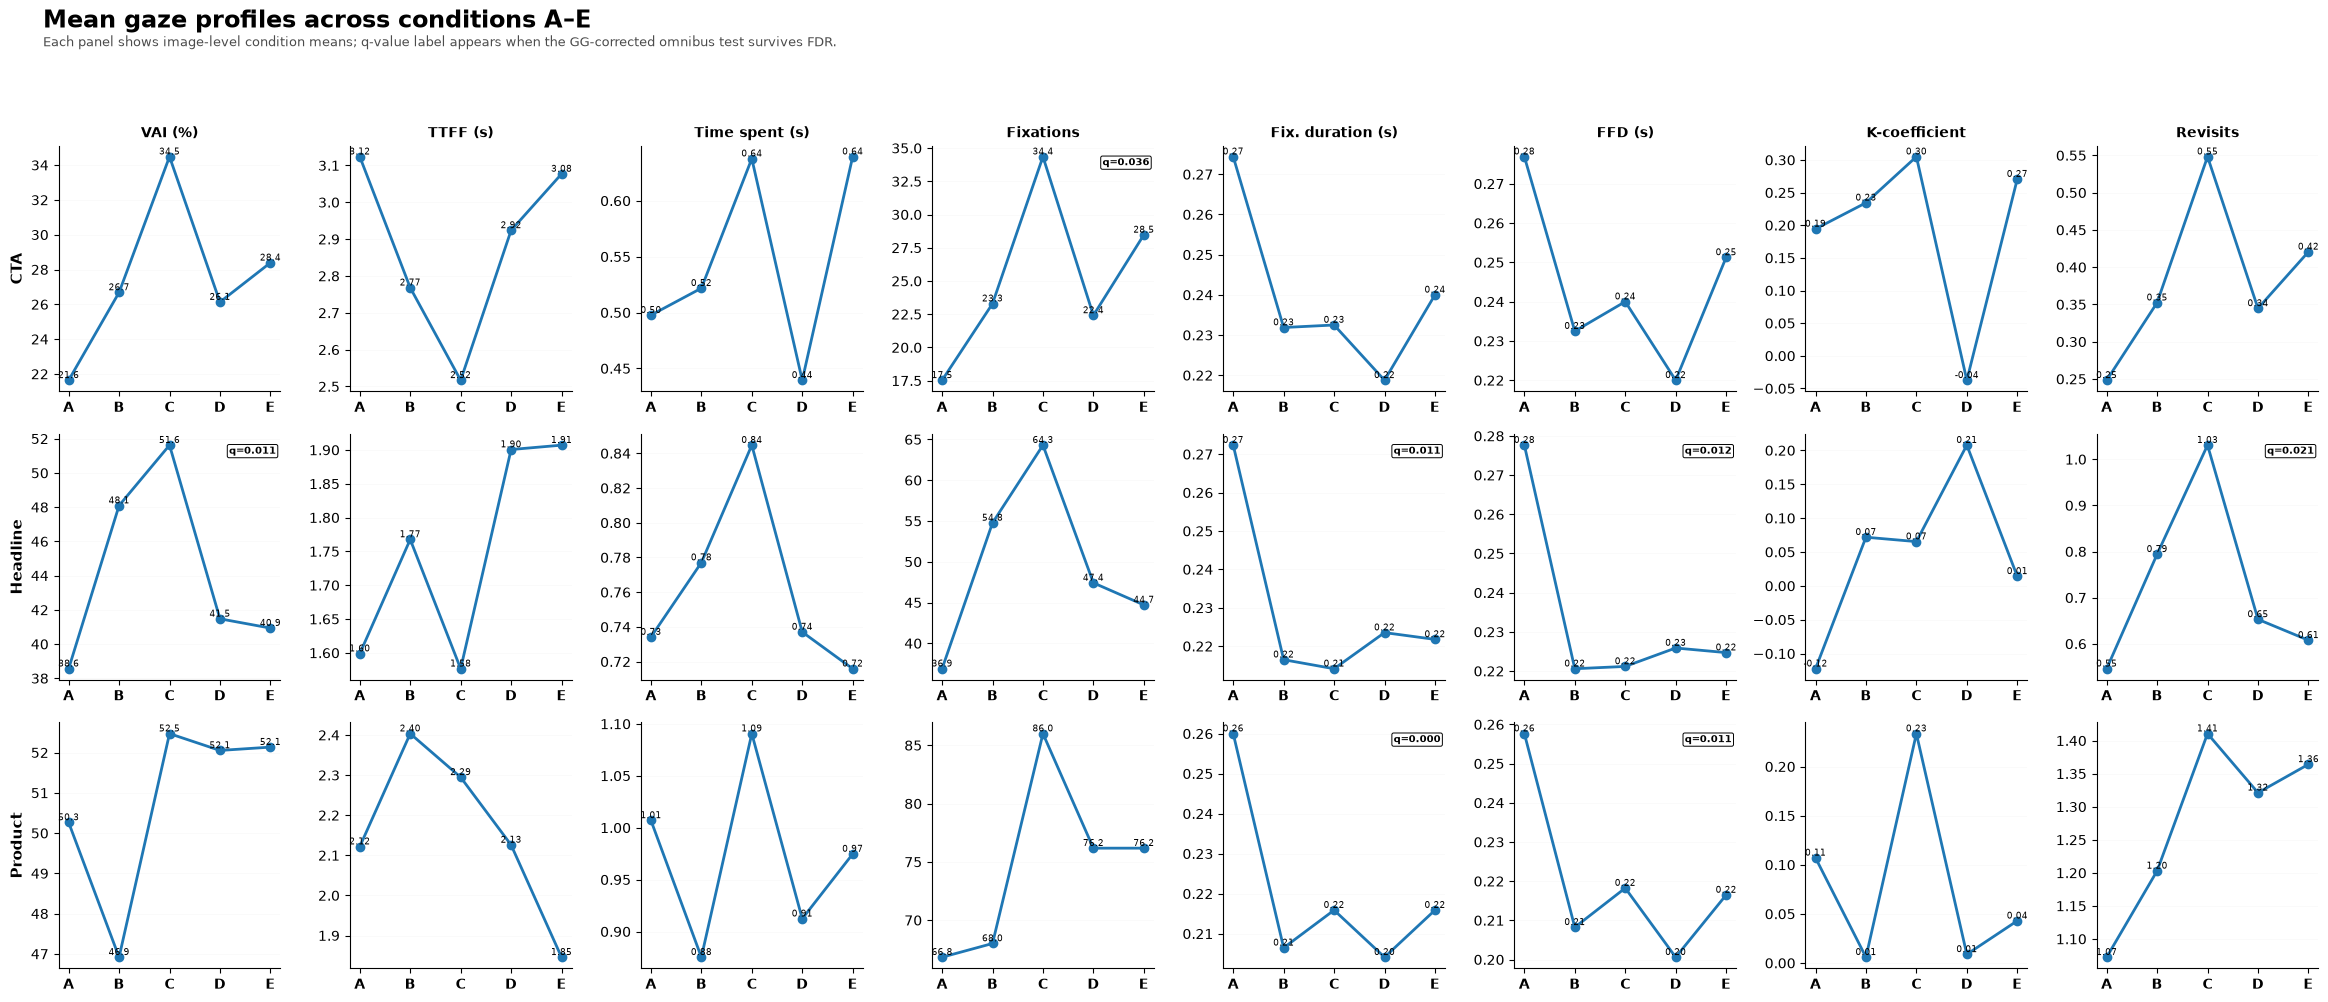

In [11]:
fig, axes = plt.subplots(
    3,
    8,
    figsize=(24, 10.5)
)

for r_idx, aoi in enumerate(AOIS):
    for c_idx, metric in enumerate(METRICS):

        ax = axes[r_idx, c_idx]

        row = omnibus[
            (omnibus["AOI"] == aoi)
            & (omnibus["metric"] == metric)
        ]

        if len(row) == 0:
            ax.set_visible(False)
            continue

        row = row.iloc[0]

        means = [
            row[f"mean_{cond}"]
            for cond in CONDITIONS
        ]

        x = np.arange(len(CONDITIONS))

        ax.plot(
            x,
            means,
            marker="o",
            linewidth=2.0,
            markersize=6
        )

        for xi, yi in zip(x, means):
            ax.text(
                xi,
                yi,
                f"{yi:.2f}" if abs(yi) < 10 else f"{yi:.1f}",
                ha="center",
                va="bottom",
                fontsize=6.5
            )

        ax.set_xticks(x)
        ax.set_xticklabels(
            CONDITIONS,
            fontweight="bold"
        )

        if r_idx == 0:
            ax.set_title(
                metric,
                fontsize=10,
                fontweight="bold"
            )

        if c_idx == 0:
            ax.set_ylabel(
                aoi,
                fontsize=11,
                fontweight="bold"
            )

        if bool(row["significant_GG_FDR"]):
            ax.text(
                0.98,
                0.95,
                f'q={row["q_GG_FDR"]:.3f}',
                transform=ax.transAxes,
                ha="right",
                va="top",
                fontsize=7,
                fontweight="bold",
                bbox=dict(
                    boxstyle="round,pad=0.18",
                    facecolor="white",
                    edgecolor="black",
                    linewidth=0.7
                )
            )

        ax.grid(
            axis="y",
            linewidth=0.45,
            alpha=0.10
        )

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

fig.suptitle(
    "Mean gaze profiles across conditions A–E",
    x=0.04,
    ha="left",
    fontsize=17,
    fontweight="bold"
)

fig.text(
    0.04,
    0.945,
    "Each panel shows image-level condition means; q-value label appears when the GG-corrected omnibus test survives FDR.",
    fontsize=9.5,
    alpha=0.70
)

fig.tight_layout(rect=[0.02, 0.03, 0.995, 0.92])

fig.savefig(
    "GG_mean_profiles_24panels.pdf",
    bbox_inches="tight"
)

fig.savefig(
    "GG_mean_profiles_24panels.png",
    dpi=500,
    bbox_inches="tight"
)

plt.show()


## Figure 3 — C-focused paired effect-size forest plot

This figure directly answers:

> How different is C from A, B, D, and E?

Positive or negative \(d_z\) indicates direction according to the order of the comparison. The confidence interval shows uncertainty.


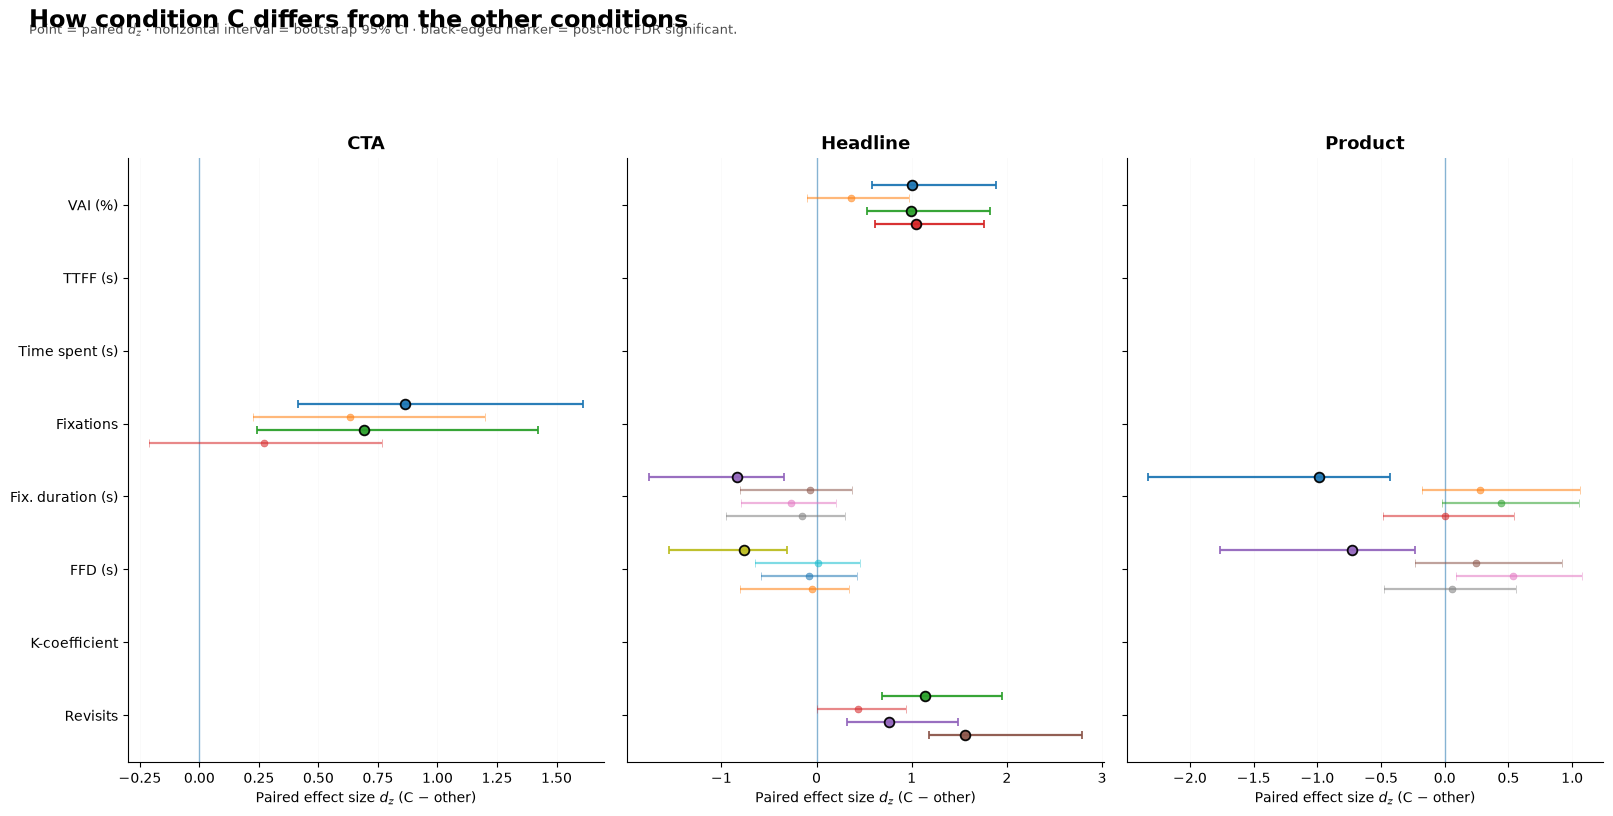

In [12]:
def pair_label(g1, g2):
    return f"{g1}–{g2}"


fig, axes = plt.subplots(
    1,
    3,
    figsize=(17, 8.5),
    sharey=True
)

pair_offsets = {
    ("A", "C"): -0.27,
    ("B", "C"): -0.09,
    ("C", "D"):  0.09,
    ("C", "E"):  0.27,
}

for ax, aoi in zip(axes, AOIS):

    sub = posthoc[
        posthoc["AOI"] == aoi
    ].copy()

    ax.axvline(
        0,
        linewidth=1.0,
        alpha=0.55,
        zorder=1
    )

    for metric_idx, metric in enumerate(METRICS):

        msub = sub[
            sub["metric"] == metric
        ]

        for pair_idx, (g1, g2) in enumerate(C_PAIRS):

            r = msub[
                (
                    (msub["group1"] == g1)
                    & (msub["group2"] == g2)
                )
                |
                (
                    (msub["group1"] == g2)
                    & (msub["group2"] == g1)
                )
            ]

            if len(r) == 0:
                continue

            r = r.iloc[0]

            # orient all comparisons as C minus the other condition
            dz = float(r["dz"])
            lo = float(r["dz_ci_low"])
            hi = float(r["dz_ci_high"])

            if r["group2"] == "C":
                oriented_dz = dz
                oriented_lo = lo
                oriented_hi = hi
                other = r["group1"]
            elif r["group1"] == "C":
                oriented_dz = -dz
                oriented_lo = -hi
                oriented_hi = -lo
                other = r["group2"]
            else:
                continue

            y = metric_idx + pair_offsets[(g1, g2)]

            left = oriented_dz - oriented_lo
            right = oriented_hi - oriented_dz

            significant = bool(
                r.get(
                    "significant_posthoc_global_FDR",
                    False
                )
            )

            ax.errorbar(
                oriented_dz,
                y,
                xerr=np.array([[left], [right]]),
                fmt="o",
                markersize=7 if significant else 5,
                capsize=3,
                elinewidth=1.6,
                markeredgecolor="black" if significant else None,
                markeredgewidth=1.3 if significant else 0.5,
                alpha=0.95 if significant else 0.55,
                label=f"C vs {other}" if metric_idx == 0 else None
            )

    ax.set_title(
        aoi,
        fontsize=13,
        fontweight="bold"
    )

    ax.set_xlabel(
        "Paired effect size $d_z$ (C − other)",
        fontsize=10
    )

    ax.grid(
        axis="x",
        linewidth=0.45,
        alpha=0.10
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

axes[0].set_yticks(np.arange(len(METRICS)))
axes[0].set_yticklabels(METRICS)
axes[0].invert_yaxis()

handles, labels = axes[-1].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.96),
    ncol=4,
    frameon=False
)

fig.suptitle(
    "How condition C differs from the other conditions",
    x=0.06,
    y=0.995,
    ha="left",
    fontsize=17,
    fontweight="bold"
)

fig.text(
    0.06,
    0.965,
    "Point = paired $d_z$ · horizontal interval = bootstrap 95% CI · black-edged marker = post-hoc FDR significant.",
    fontsize=9.5,
    alpha=0.70
)

fig.tight_layout(
    rect=[0.04, 0.04, 0.995, 0.91]
)

fig.savefig(
    "GG_C_focused_effect_forest.pdf",
    bbox_inches="tight"
)

fig.savefig(
    "GG_C_focused_effect_forest.png",
    dpi=500,
    bbox_inches="tight"
)

plt.show()


## Outputs

The notebook generates:

```text
GG_omnibus_effect_map.pdf
GG_mean_profiles_24panels.pdf
GG_C_focused_effect_forest.pdf
```

plus matching PNG files.

### Recommended use

- **`GG_omnibus_effect_map.pdf`** → compact overview of which metrics show a condition effect.
- **`GG_mean_profiles_24panels.pdf`** → visual inspection of A–E patterns.
- **`GG_C_focused_effect_forest.pdf`** → strongest figure for interpreting how C differs from the other conditions.
